In [19]:
import json
from datetime import datetime

import pandas as pd

from multiple_choice import construct_multiple_choice_question_pretty
from utils import load_all_llm_answers_from_json

## TO DO
- HEATMAP of each model and whether they get the same questions wrong or not
- Add probabilistic outputs to each model answer
- Add "abstain" option for all models

In [20]:
answers_save_path = "./2025-04-26-Multi-Benchmark/auto_eval_outputs"

all_llm_answers = load_all_llm_answers_from_json(answers_save_path, prefix_replace="auto_eval-")

all_llm_answers

{'claude-3_5-sonnet':     level_0  index         category  \
 0         0      1           Puzzle   
 1         1      2           Puzzle   
 2         2      3          Spatial   
 3         3      4           Puzzle   
 4         4      5           Puzzle   
 ..      ...    ...              ...   
 85       85     26           Puzzle   
 86       86     27           Puzzle   
 87       87     28  Popular science   
 88       88     29       Relational   
 89       89     30  Popular science   
 
                                              question  \
 0   You have six horses and want to race them to s...   
 1   Suppose you're on a game show, and you're give...   
 2   You are playing Russian roulette with a six-sh...   
 3   A farmer wants to cross a river and take with ...   
 4   Bob has three boxes in front of him - Box A, B...   
 ..                                                ...   
 85  A runaway trolley is heading down the tracks a...   
 86  How do you efficiently measu

In [21]:
all_llm_answers[list(all_llm_answers.keys())[0]].head(1)

,level_0,index,category,question,human_answer,correct_answer,multiple_choice,multi_choice_question,correct_letter,model_answer,score,json_answer,json_answer_letter,invalid_answer_letter
0,0,1,Puzzle,You have six horses and want to race them to s...,Race them on a single race track with at least...,One,"[Three, Two, Unknown, One]",<MULTIPLE CHOICE QUESTION>\nYou have six horse...,D,"{""ANSWER"": ""A"", ""SHORT EXPLANATION"": ""To find ...",0,"{'ANSWER': 'A', 'SHORT EXPLANATION': 'To find ...",A,0


In [22]:
# # Sanity check to see if the scores are being calculated correctly in the below cells after a low of manipulation
# model_scores = []
# for llm_model in list(all_llm_answers.keys()):
#     correct_answer = all_llm_answers[llm_model]['correct_letter'] == all_llm_answers[llm_model]['json_answer_letter']
#     percentage_correct = correct_answer.value_counts(normalize=True)[True] * 100
#     initial_score = all_llm_answers[llm_model]['score'].mean()
#     dict_results = {
#         'model': llm_model,
#         'percentage_correct': percentage_correct,
#         'initial_score': initial_score
#     }
#     model_scores.append(dict_results)

# model_scores_series = pd.DataFrame(model_scores).sort_values(by='percentage_correct', ascending=False)
# model_scores_series

In [23]:
moe_llm_answers = {}
for llm_model in list(all_llm_answers.keys()):
    answer_subset = all_llm_answers[llm_model]
    data = answer_subset[
        [
            "index",
            "question",
            "multiple_choice",
            "correct_answer",
            "multi_choice_question",
            "correct_letter",
            "json_answer_letter",
        ]
    ]
    moe_llm_answers[llm_model] = []
    for idx, row in data.iterrows():
        # if idx > 0:
        #     continue
        normalized_choices_dict_inv = dict(
            zip(sorted(row["multiple_choice"]), ["A", "B", "C", "D"])
        )
        presented_choices_dict = dict(zip(["A", "B", "C", "D"], row["multiple_choice"]))
        correct_answer = presented_choices_dict[row["correct_letter"]]
        row["correct"] = row["correct_letter"] == row["json_answer_letter"]
        assert row["correct_answer"] == correct_answer
        normalized_correct_letter = normalized_choices_dict_inv[correct_answer]
        if row["json_answer_letter"] not in presented_choices_dict:
            selected_answer, normalized_choice_letter = None, None
        else:
            selected_answer = presented_choices_dict[row["json_answer_letter"]]
            normalized_choice_letter = normalized_choices_dict_inv[selected_answer]
        moe_llm_answers[llm_model].append(
            {
                "q_index": row["index"],
                "question": row["question"],
                # 'selected_answer': selected_answer,
                # 'correct_answer': correct_answer,
                "correct": row["correct"],
                "normalized_correct_letter": normalized_correct_letter,
                "normalized_choice_letter": normalized_choice_letter,
            }
        )
        # print(f"idx: {idx} | {llm_model} | {moe_llm_answers[llm_model]}\n")

In [24]:
moe_llm_answers_comb_df = {}
for llm_model in list(all_llm_answers.keys()):
    data = pd.DataFrame(moe_llm_answers[llm_model])
    data.reset_index(drop=False, inplace=True)
    columns_mapping = {
        "index": ("bench", "index"),
        "q_index": ("bench", "q_index"),
        "question": ("bench", "question"),
        "normalized_correct_letter": ("bench", "normalized_correct_letter"),
        "normalized_choice_letter": (llm_model, "normalized_choice_letter"),
        "correct": (llm_model, "correct"),
    }
    grouped_columns_map = [columns_mapping[col] for col in data.columns if col in columns_mapping]
    grouped_columns = pd.MultiIndex.from_tuples(grouped_columns_map)
    data.columns = grouped_columns
    data
    if len(moe_llm_answers_comb_df) == 0:
        moe_llm_answers_comb_df = data
    else:
        moe_llm_answers_comb_df = pd.merge(
            moe_llm_answers_comb_df,
            data,
            on=[
                ("bench", "index"),
                ("bench", "question"),
                ("bench", "normalized_correct_letter"),
                ("bench", "q_index"),
            ],
        )

assert len(moe_llm_answers_comb_df) == len(all_llm_answers[list(all_llm_answers.keys())[0]]), (
    "Unable to reliably merge based on index, question, and normalized_correct_letter. This might suggest that the data is inconsistent or inaccurate"
)

moe_llm_answers_comb_df

bench                                                             \
   index q_index                                           question   
0      0       1  You have six horses and want to race them to s...   
1      1       2  Suppose you're on a game show, and you're give...   
2      2       3  You are playing Russian roulette with a six-sh...   
3      3       4  A farmer wants to cross a river and take with ...   
4      4       5  Bob has three boxes in front of him - Box A, B...   
..   ...     ...                                                ...   
85    85      26  A runaway trolley is heading down the tracks a...   
86    86      27  How do you efficiently measure exactly 4 gallo...   
87    87      28  A 2kg tree grows in a planted pot with 10kg of...   
88    88      29  A man steps over a 0.5m hurdle. What is the mi...   
89    89      30  I walk to my friend's house, averaging 3mph. H...   

   claude-3_5-sonnet                     bench        claude-3_5-sonnet  \
             correct normalized_correct_letter normalized_choice_letter   
0              False                         A                        B   
1              False                         D                        B   
2               True                         D                        D   
3              False                         B                        A   
4               True                         A                        A   
..               ...                       ...                      ...   
85              True                         A                        A   
86             False                         A                        B   
87             False                         A                        D   
88             False                         B                        D   
89             False                         D                        C   

   claude-3_7-sonnet                          claude-3_7-sonnet_thinking  \
             correct normalized_choice_letter                    correct   
0               True                        A                       True   
1              False                        B                       True   
2               True                        D                       True   
3               True                        B                       True   
4              False                        C                       True   
..               ...                      ...                        ...   
85              True                        A                       True   
86             False                        B                      False   
87             False                        D                      False   
88              True                        B                      False   
89             False                        C                       True   

                             ... o4-mini-high                           \
   normalized_choice_letter  ...      correct normalized_choice_letter   
0                         A  ...         True                        A   
1                         D  ...        False                        B   
2                         D  ...         True                        D   
3                         B  ...         True                        B   
4                         A  ...         True                        A   
..                      ...  ...          ...                      ...   
85                        A  ...        False                        B   
86                        B  ...        False                        D   
87                        D  ...         True                        A   
88                        D  ...        False                        D   
89                        D  ...         True                        D   

   o4-mini                          qwen-2_5-coder-32b-instruct  \
   correct normalized_choice_letter                     correct   
0     True       

In [25]:
llm_models = list(all_llm_answers.keys())
norm_choice_cols = list(zip(llm_models, ["normalized_choice_letter"] * len(llm_models)))
norm_correct_cols = list(zip(llm_models, ["correct"] * len(llm_models)))
norm_choice_cols

[('claude-3_5-sonnet', 'normalized_choice_letter'),
 ('claude-3_7-sonnet', 'normalized_choice_letter'),
 ('claude-3_7-sonnet_thinking', 'normalized_choice_letter'),
 ('codestral-2501', 'normalized_choice_letter'),
 ('command-a', 'normalized_choice_letter'),
 ('deepseek-chat-v3-0324', 'normalized_choice_letter'),
 ('deepseek-r1-zero_free', 'normalized_choice_letter'),
 ('deepseek-r1', 'normalized_choice_letter'),
 ('gemini-2_5-flash-preview_thinking', 'normalized_choice_letter'),
 ('gemini-2_5-pro-preview-03-25', 'normalized_choice_letter'),
 ('gemma-3-27b-it', 'normalized_choice_letter'),
 ('gpt-4o-2024-11-20', 'normalized_choice_letter'),
 ('gpt-4_1', 'normalized_choice_letter'),
 ('gpt-4_5-preview', 'normalized_choice_letter'),
 ('grok-3-beta', 'normalized_choice_letter'),
 ('grok-3-mini-beta', 'normalized_choice_letter'),
 ('llama-4-maverick', 'normalized_choice_letter'),
 ('mistral-large-2411', 'normalized_choice_letter'),
 ('o1-pro', 'normalized_choice_letter'),
 ('o1', 'normalize

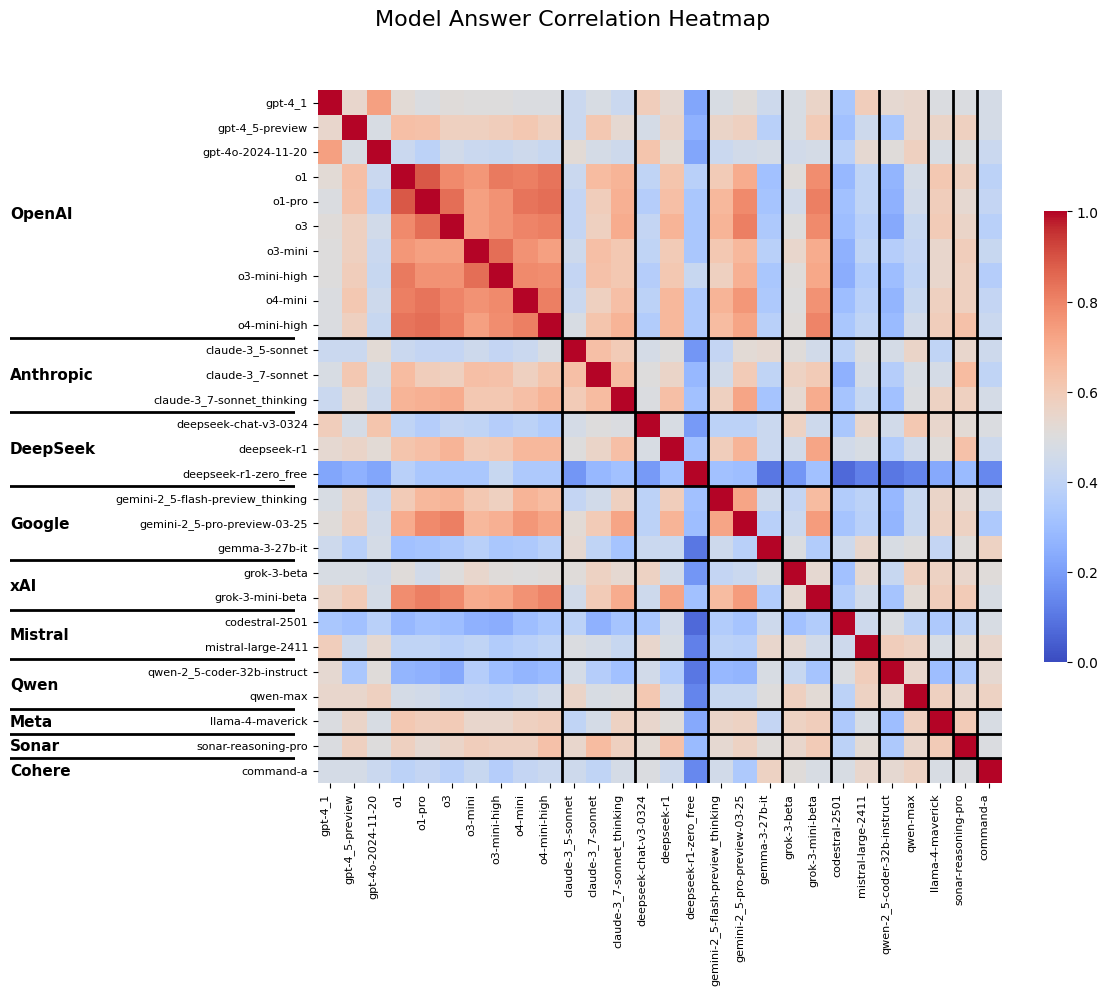

In [26]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣  ── Tell the script which provider each model belongs to
provider_map = {
    # Anthropic
    "claude-3_5-sonnet": "Anthropic",
    "claude-3_7-sonnet": "Anthropic",
    "claude-3_7-sonnet_thinking": "Anthropic",
    # OpenAI
    "gpt-4o-2024-11-20": "OpenAI",
    "gpt-4_1": "OpenAI",
    "gpt-4_5-preview": "OpenAI",
    "o1-pro": "OpenAI",
    "o1": "OpenAI",
    "o3-mini-high": "OpenAI",
    "o3-mini": "OpenAI",
    "o3": "OpenAI",
    "o4-mini-high": "OpenAI",
    "o4-mini": "OpenAI",
    # xAI / Grok
    "grok-3-beta": "xAI",
    "grok-3-mini-beta": "xAI",
    # DeepSeek
    "deepseek-chat-v3-0324": "DeepSeek",
    "deepseek-r1-zero_free": "DeepSeek",
    "deepseek-r1": "DeepSeek",
    # Google
    "gemini-2_5-flash-preview_thinking": "Google",
    "gemini-2_5-pro-preview-03-25": "Google",
    "gemma-3-27b-it": "Google",
    # Meta
    "llama-4-maverick": "Meta",
    # Mistral
    "mistral-large-2411": "Mistral",
    "codestral-2501": "Mistral",
    # Qwen
    "qwen-2_5-coder-32b-instruct": "Qwen",
    "qwen-max": "Qwen",
    # Sonar
    "sonar-reasoning-pro": "Sonar",
    # Other
    "command-a": "Cohere",
}

# 2️⃣  ── Order models by provider, then alphabetically inside each group
provider_order = [
    "OpenAI",
    "Anthropic",
    "DeepSeek",
    "Google",
    "xAI",
    "Mistral",
    "Qwen",
    "Meta",
    "Sonar",
    "Cohere",
]

# -----------------------------------------------------------------------------
#  2.  BUILD THE CORRELATION MATRIX  (your original logic)
# -----------------------------------------------------------------------------
answer_correlations = {}
for model_base, col in norm_choice_cols:
    model_correlations = {}
    for model_test, _ in norm_choice_cols:
        same_pct = (
            moe_llm_answers_comb_df[model_base][col].fillna(0)
            == moe_llm_answers_comb_df[model_test][col].fillna(0)
        ).value_counts(normalize=True)[True]
        model_correlations[model_test] = same_pct
    answer_correlations[model_base] = model_correlations

correlation_matrix = pd.DataFrame(answer_correlations)

# -----------------------------------------------------------------------------
#  3.  ORDER MODELS  &  FIND PROVIDER BOUNDARIES
# -----------------------------------------------------------------------------
sorted_models = sorted(
    correlation_matrix.index, key=lambda m: (provider_order.index(provider_map[m]), m)
)
corr_sorted = correlation_matrix.loc[sorted_models, sorted_models]

boundaries = []
last = provider_map[sorted_models[0]]
for i, m in enumerate(sorted_models):
    if provider_map[m] != last:
        boundaries.append(i)  # boundary is BEFORE row i
        last = provider_map[m]

# -----------------------------------------------------------------------------
#  4.  PLOT  (GridSpec: | provider labels | heat-map | )
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 6], wspace=0.04)

ax_lbl = fig.add_subplot(gs[0])  # left gutter
ax_hm = fig.add_subplot(gs[1])  # heat-map

# -- heat-map ---------------------------------------------------------------
sns.heatmap(corr_sorted, cmap="coolwarm", vmin=0, vmax=1, ax=ax_hm, cbar_kws={"shrink": 0.65})

# -- label gutter -----------------------------------------------------------
ax_lbl.set_ylim(ax_hm.get_ylim())  # match y-range
ax_lbl.set_xticks([])
ax_lbl.set_yticks([])
ax_lbl.set_frame_on(False)  # hide border

starts = [0] + boundaries
ends = boundaries + [len(sorted_models)]

for s, e in zip(starts, ends):
    mid = s + (e - s) / 2
    provider = provider_map[sorted_models[s]]
    ax_lbl.text(
        0.0,
        mid,  # x=0  → flush with left edge
        provider,
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

# -- guide-lines ------------------------------------------------------------
for b in boundaries:
    ax_hm.axhline(b, color="black", lw=2)
    ax_lbl.axhline(b, color="black", lw=2)
    ax_hm.axvline(b, color="black", lw=2)

# -- cosmetics --------------------------------------------------------------
ax_hm.set_xticklabels(ax_hm.get_xticklabels(), rotation=90, ha="right", fontsize=8)
ax_hm.set_yticklabels(ax_hm.get_yticklabels(), rotation=0, fontsize=8)
fig.suptitle("Model Answer Correlation Heatmap", fontsize=16, y=0.97)

plt.show()


### Run test to see how MOE performs with various permutations of models

In [27]:
# Sanity check to see if model scores match those calculated earlier (because we have done a lot of messing about).
# It can used as a basis to see if MOE is improving results or not.
result_series = pd.Series(
    {
        col[0]: (
            moe_llm_answers_comb_df[col]
            == moe_llm_answers_comb_df["bench"]["normalized_correct_letter"]
        ).value_counts(normalize=True)[True]
        for col in norm_choice_cols
    }
)

result_series.sort_values(ascending=False)

gemini-2_5-pro-preview-03-25         0.766667
o1-pro                               0.733333
o3                                   0.733333
o4-mini                              0.711111
o4-mini-high                         0.655556
o3-mini                              0.655556
grok-3-mini-beta                     0.644444
o1                                   0.644444
claude-3_7-sonnet_thinking           0.644444
o3-mini-high                         0.611111
gemini-2_5-flash-preview_thinking    0.588889
deepseek-r1                          0.566667
claude-3_7-sonnet                    0.511111
gpt-4_5-preview                      0.477778
llama-4-maverick                     0.477778
sonar-reasoning-pro                  0.466667
claude-3_5-sonnet                    0.411111
gpt-4o-2024-11-20                    0.366667
gpt-4_1                              0.366667
grok-3-beta                          0.322222
qwen-max                             0.288889
deepseek-chat-v3-0324             

In [28]:
import numpy as np


def get_most_common_or_best_model(row, best_model_rank=None):
    # Get the value counts for the row, if all NaNs, return a random choice
    value_counts = row.value_counts()
    if value_counts.empty:  # Check if value_counts is empty (all values are NaN)
        return np.random.choice(["A", "B", "C", "D"])
    else:
        # Find the maximum count
        max_count = value_counts.max()
        # Find the indices (letters) that have the maximum count
        most_common_choices = value_counts[value_counts == max_count].index.tolist()
        # If there's more than one most frequent letter, pick one given rules
        if len(most_common_choices) > 1:
            if best_model_rank is not None:
                for best_model in best_model_rank:
                    if row[best_model]["normalized_choice_letter"] in most_common_choices:
                        return row[best_model]["normalized_choice_letter"]
            else:
                return np.random.choice(most_common_choices)
        else:
            return most_common_choices[0]


# # Remove '['normalized_choice_letter']' from return function to run mock test below
# model_data_test = pd.DataFrame([
#     {'One': 'A', 'Two': 'A', 'Three': 'B', 'Four': 'B'},
#     {'One': 'C', 'Two': 'B', 'Three': 'C', 'Four': 'B'},
#     {'One': 'A', 'Two': 'B', 'Three': 'C', 'Four': 'D'},
#     ])

# best_model_rank = ['Four', 'Three', 'Two', 'One']
# most_common_answer = model_data_test.apply(axis='columns',
#     func=lambda x: get_most_common_or_best_model(x, best_model_rank), result_type='expand')

# most_common_answer

In [29]:
subset_of_models = [
    "gemini-2_5-pro-preview-03-25",
    "o1-pro",
    "o3",
    "o4-mini",
    "o4-mini-high",
    "o3-mini",
    "grok-3-mini-beta",
    "o1",
    "claude-3_7-sonnet_thinking",
    "o3-mini-high",
    "gemini-2_5-flash-preview_thinking",
    "deepseek-r1",
    "claude-3_7-sonnet",
    "gpt-4_5-preview",
    "llama-4-maverick",
    "sonar-reasoning-pro",
    "claude-3_5-sonnet",
    "gpt-4o-2024-11-20",
    "gpt-4_1",
    "grok-3-beta",
    "qwen-max",
    "deepseek-chat-v3-0324",
    "deepseek-r1-zero_free",
    "codestral-2501",
    "gemma-3-27b-it",
    "command-a",
    "mistral-large-2411",
    "qwen-2_5-coder-32b-instruct",
]
# subset_norm_choice_cols = [col for col in norm_choice_cols if col[0] in subset_of_models]
# subset_norm_correct_cols = [col for col in norm_correct_cols if col[0] in subset_of_models]

# subset_norm_choice_cols = norm_choice_cols
# subset_norm_correct_cols = norm_correct_cols


subset_norm_choice_cols = [(m, "normalized_choice_letter") for m in subset_of_models]
subset_norm_correct_cols = [(m, "correct") for m in subset_of_models]

In [30]:
moe_llm_answers_comb_df[["gemini-2_5-pro-preview-03-25", "bench"]].groupby(
    [("bench", "q_index")]
).sum().head()

gemini-2_5-pro-preview-03-25                          bench  \
                                      correct normalized_choice_letter index   
(bench, q_index)                                                               
1                                           3                      AAA    90   
2                                           3                      DDD    93   
3                                           3                      DDD    96   
4                                           3                      BBB    99   
5                                           1                      CAC   102   

                                                                     \
                                                           question   
(bench, q_index)                                                      
1                 You have six horses and want to race them to s...   
2                 Suppose you're on a game show, and you're give...   
3                 You are playing Russian roulette with a six-sh...   
4                 A farmer wants to cross a river and take with ...   
5                 Bob has three boxes in front of him - Box A, B...   

                                            
                 normalized_correct_letter  
(bench, q_index)                            
1                                      AAA  
2                                      DDD  
3                                      DDD  
4                                      BBB  
5                                      AAA

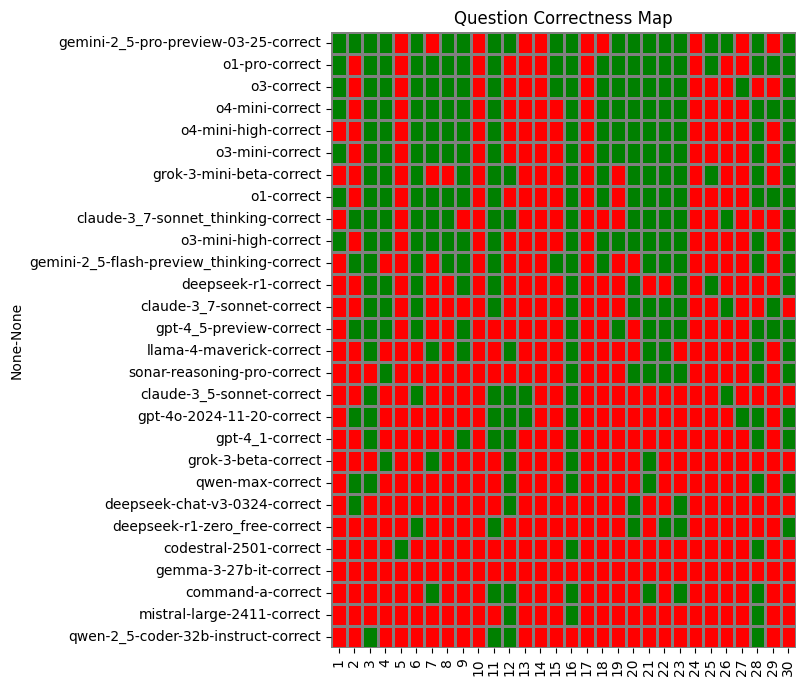

In [31]:
question_correct_df = (
    moe_llm_answers_comb_df[subset_norm_correct_cols + [("bench", "q_index")]]
    .groupby([("bench", "q_index")])
    .min()  # They got it right once
    .reset_index(drop=True)
)
question_correct_df.index += 1

plt.figure(figsize=(6, 8))
plt.title("Question Correctness Map")
cmap = sns.color_palette(["red", "green"])
sns.heatmap(question_correct_df.T, cmap=cmap, cbar=False, linewidths=1, linecolor="grey")
# plt.xticks(rotation=0, ha='right')
None

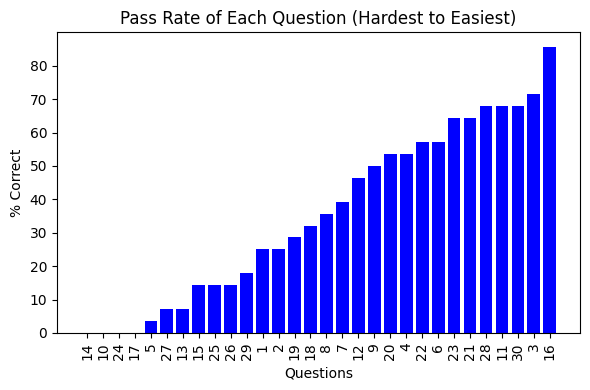

In [32]:
qs_correct = question_correct_df.transpose().sum(axis=0)
qs_correct_percent = round((qs_correct / len(subset_of_models) * 100), 1)
qs_correct_percent = qs_correct_percent.sort_values(ascending=True)
# plot the percentage of questions answered correctly
plt.figure(figsize=(6, 4))
plt.bar(range(len(qs_correct_percent)), qs_correct_percent, color="blue")
plt.xticks(range(len(qs_correct_percent)), qs_correct_percent.index, rotation=90)
plt.xlabel("Questions")
plt.ylabel("% Correct")
plt.title("Pass Rate of Each Question (Hardest to Easiest)")
plt.tight_layout()

In [33]:
qs_correct_percent.index.name = "question"
qs_correct_percent.name = "pass_rate"
qs_correct_percent.sort_index(ascending=True).to_csv(
    "qs_correct_percent.csv",
    header=True,
    index=True,
)
qs_correct_percent.index

Index([14, 10, 24, 17,  5, 27, 13, 15, 25, 26, 29,  1,  2, 19, 18,  8,  7, 12,
        9, 20,  4, 22,  6, 23, 21, 28, 11, 30,  3, 16],
      dtype='int64', name='question')

In [ ]:
# Formats the questions and joins that with the qs_correct_percent result.
# Lastly, order the questions by the pass rate.

json_file = "./linguistic_benchmark_multi_choice.json"
with open(json_file, "r", encoding="utf-8") as f:  # open utf8
    data = json.load(f)

nice_human_readable = ""

# for idx in qs_correct_percent.index:
for idx in range(1, len(data) + 1):
    question = data[idx - 1]
    q_index = question["index"]
    ai_pass_rate = qs_correct_percent[q_index]
    print(f"Question {question}")
    question_str, letter = construct_multiple_choice_question_pretty(
        question, q_index, ai_pass_rate
    )
    nice_human_readable += question_str + "\n---------------------------\n\n"


print(nice_human_readable)

Question {'index': 10, 'category': 'Relational', 'question': 'I walk out of the top floor (third floor) at street level. How many stories is the building above the street level', 'human_answer': 'One story above street level, as exiting at street level requires a single story building.', 'correct_answer': 'One story above street level', 'multiple_choice': ['Zero stories above street level', 'One story above street level', 'Two stories above street level', 'Three stories above street level']}
Question {'index': 12, 'category': 'Spatial', 'question': "Four children - Alex, Bella, Charlie, and Dana - are sitting at a four-person table with two sides. Alex is sitting opposite Bella. Charlie is sitting to Bella's right. Who is sitting to the left of Alex?", 'human_answer': 'Dana', 'correct_answer': "'Dana'", 'multiple_choice': ["'Bella'", "'Charlie'", "'Dana'", 'No one']}
Question {'index': 13, 'category': 'Spatial', 'question': 'A man leaves home, at 0m elevation (the lowest point), looks 

In [35]:
raise

RuntimeError: No active exception to reraise

## Find the best combination of models to get the most correct answers

In [ ]:
best_model_rank = None  # list(result_series.sort_values(ascending=False).index.values)

answer_values = moe_llm_answers_comb_df.apply(
    axis="columns", func=lambda x: x[subset_norm_choice_cols].value_counts()
)
most_common_answer = moe_llm_answers_comb_df.apply(
    axis="columns",
    func=lambda x: get_most_common_or_best_model(x[subset_norm_choice_cols], best_model_rank),
    result_type="expand",
)
largest_common_answer = moe_llm_answers_comb_df.apply(
    axis="columns", func=lambda x: x[subset_norm_choice_cols].value_counts().max()
)
answer_values["correct_letter"] = moe_llm_answers_comb_df["bench"]["normalized_correct_letter"]
answer_values["most_common_answer"] = most_common_answer
answer_values["largest_common_answer"] = largest_common_answer
display(answer_values)

correct = (answer_values["correct_letter"] == answer_values["most_common_answer"]).sum() / len(
    answer_values
)
print("Score %:", correct)

In [ ]:
answer_values["correct"] = (
    answer_values["correct_letter"] == answer_values["most_common_answer"]
).astype(int)
accuracy_by_vote_agg = answer_values[["largest_common_answer", "correct"]].groupby(
    "largest_common_answer"
)
accuracy_by_vote_agg.mean().plot(kind="bar", title="Accuracy by Most Common Answer")
accuracy_by_vote_agg.count().plot(kind="bar", title="Accuracy by Most Common Answer")
print(f"Highest accuracy: {accuracy_by_vote_agg.mean().max().values[0]:.2%}")

In [ ]:
from itertools import combinations


def all_combinations(arr):
    x = len(arr)
    all_combos = []
    for r in range(2, x + 1):
        combos = list(combinations(arr, r))
        all_combos.extend(combos)
    return all_combos


all_combos = all_combinations(llm_models)
all_combos

In [ ]:
raise

In [ ]:
from tqdm import tqdm

all_combo_results = {}
for models in tqdm(all_combos):
    subset_norm_choice_cols = [col for col in norm_choice_cols if col[0] in models]
    answer_values = moe_llm_answers_comb_df.apply(
        axis="columns", func=lambda x: x[subset_norm_choice_cols].value_counts()
    )
    most_common_answer = moe_llm_answers_comb_df.apply(
        axis="columns",
        func=lambda x: get_most_common_or_best_model(x[subset_norm_choice_cols]),
        result_type="expand",
    )
    largest_common_answer = moe_llm_answers_comb_df.apply(
        axis="columns", func=lambda x: x[subset_norm_choice_cols].value_counts().max()
    )
    answer_values["correct_letter"] = moe_llm_answers_comb_df["bench"]["normalized_correct_letter"]
    answer_values["most_common_answer"] = most_common_answer
    answer_values["largest_common_answer"] = largest_common_answer
    # display(answer_values)

    correct = (answer_values["correct_letter"] == answer_values["most_common_answer"]).sum() / len(
        answer_values
    )
    # print(f'Models: {models} | Score %: {correct}')
    all_combo_results[models] = correct

In [ ]:
max_score = 0
for models, score in all_combo_results.items():
    if score > max_score:
        max_score = score
        print(f"Models: {models} | Score %: {score}")

In [ ]:
pd.DataFrame(all_combo_results, index=["score"]).T.sort_values(
    by="score", ascending=False
)  # .to_csv('./all_combo_results.csv')